# Alternative Label, Integrity Model, Calibration & Booster/Ensemble

Four additions that strengthen the study:

1. **Residual-based alternative label** — an independent, physics-grounded 'this measurement is faulty' label derived from the pseudorange residual against the *true* trajectory, used to **validate (or challenge) the device `MultipathIndicator` flag**.
2. **Integrity model** — predict whether an *epoch's position* is untrustworthy from epoch-level features (the forward-looking, fusion-facing use of detection).
3. **Calibration diagrams** — reliability curves that formalise the cross-domain calibration shift.
4. **Booster + ensemble** — a HistGradientBoosting booster and a soft-voting ensemble, for completeness against the Random Forest.

## 0. Setup & geodesy

In [1]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../..'))
TRAIN = os.path.join(BASE_DIR, 'data/01_raw/sdc2023/train')
WARWICK = os.path.join(BASE_DIR, 'data/01_raw/Warwick')
C = 299792458.0; OMEGA_E = 7.2921151467e-5; A = 6378137.0; F = 1/298.257223563; E2 = F*(2-F)

def geo_to_ecef(lat, lon, h):
    lat, lon = np.radians(lat), np.radians(lon); N = A/np.sqrt(1-E2*np.sin(lat)**2)
    return np.column_stack([(N+h)*np.cos(lat)*np.cos(lon), (N+h)*np.cos(lat)*np.sin(lon), (N*(1-E2)+h)*np.sin(lat)])
def ecef_to_geo(x,y,z):
    lon=np.arctan2(y,x); p=np.hypot(x,y); lat=np.arctan2(z,p*(1-E2))
    for _ in range(6):
        N=A/np.sqrt(1-E2*np.sin(lat)**2); h=p/np.cos(lat)-N; lat=np.arctan2(z,p*(1-E2*N/(N+h)))
    return np.degrees(lat), np.degrees(lon)
def hav(a,b,c,d):
    R=6371000.0; dl=np.radians(c-a); do=np.radians(d-b)
    return 2*R*np.arcsin(np.sqrt(np.sin(dl/2)**2+np.cos(np.radians(a))*np.cos(np.radians(c))*np.sin(do/2)**2))

def range_to(sat, ref):
    r0 = np.linalg.norm(sat-ref, axis=1); th = OMEGA_E*r0/C
    satr = np.column_stack([np.cos(th)*sat[:,0]+np.sin(th)*sat[:,1], -np.sin(th)*sat[:,0]+np.cos(th)*sat[:,1], sat[:,2]])
    return np.linalg.norm(satr-ref, axis=1)

SESSIONS = [('2023-09-06-00-01-us-ca-routen','pixel6pro'), ('2023-09-06-00-01-us-ca-routen','sm-g955f'),
            ('2023-09-07-22-47-us-ca-routebc2','pixel6pro'), ('2023-05-24-20-26-us-ca-sjc-ge2','pixel7pro'),
            ('2023-09-06-18-47-us-ca','pixel6pro'), ('2023-09-07-19-33-us-ca','pixel6pro')]
print('setup ok |', len(SESSIONS), 'session/device pairs pooled')

setup ok | 6 session/device pairs pooled


## 1. A physics-based residual label — and how well it matches the device flag

For every measurement we compute the pseudorange residual against the **true** trajectory (satellite-to-true-position range, minus the corrected pseudorange, de-meaned per epoch/constellation to strip the receiver clock). A large `|residual|` means the measurement is physically inconsistent with where the vehicle actually was — a genuine multipath/NLOS fault. We compare this to the device `MultipathIndicator`.

In [2]:
def load_meas(session, device):
    d = os.path.join(TRAIN, session, device)
    g = pd.read_csv(os.path.join(d, 'device_gnss.csv'), low_memory=False)
    gt = pd.read_csv(os.path.join(d, 'ground_truth.csv')).dropna(subset=['LatitudeDegrees','LongitudeDegrees']).sort_values('UnixTimeMillis')
    for c in ['SvClockBiasMeters','IsrbMeters','IonosphericDelayMeters','TroposphericDelayMeters']: g[c]=g[c].fillna(0)
    g['pr_corr'] = g.RawPseudorangeMeters + g.SvClockBiasMeters - g.IsrbMeters - g.IonosphericDelayMeters - g.TroposphericDelayMeters
    g = g[g.RawPseudorangeMeters.between(1e6,5e7) & g.SvPositionXEcefMeters.notna() & g.SvElevationDegrees.fillna(0).ge(5)].copy()
    gi = np.clip(np.searchsorted(gt.UnixTimeMillis.values, g.utcTimeMillis.values), 0, len(gt)-1)
    true_ecef = geo_to_ecef(gt.LatitudeDegrees.values[gi], gt.LongitudeDegrees.values[gi], gt.AltitudeMeters.fillna(0).values[gi])
    sat = g[['SvPositionXEcefMeters','SvPositionYEcefMeters','SvPositionZEcefMeters']].values
    g['resid0'] = g.pr_corr.values - range_to(sat, true_ecef)
    g['resid'] = g.resid0 - g.groupby(['utcTimeMillis','ConstellationType']).resid0.transform('median')
    g['abs_resid'] = g.resid.abs()
    g['az_sin'] = np.sin(np.radians(g.SvAzimuthDegrees)); g['az_cos'] = np.cos(np.radians(g.SvAzimuthDegrees))
    g['device_mp'] = (g.MultipathIndicator==1).astype(int)
    g['sess'] = session+'/'+device
    return g

M = pd.concat([load_meas(s,d) for s,d in SESSIONS], ignore_index=True)
FAULT_THR = 15.0   # metres
M['resid_fault'] = (M.abs_resid > FAULT_THR).astype(int)
print(f'Pooled measurements: {len(M):,}')
print(f'device-flag multipath rate: {100*M.device_mp.mean():.1f}%   |   residual-fault (|r|>{FAULT_THR:.0f} m) rate: {100*M.resid_fault.mean():.1f}%')

Pooled measurements: 281,109
device-flag multipath rate: 7.7%   |   residual-fault (|r|>15 m) rate: 6.3%


In [3]:
print('=== Residual-fault vs device MultipathIndicator ===')
ct = pd.crosstab(M.resid_fault.rename('residual_fault'), M.device_mp.rename('device_flag'))
print(ct)
overlap = M[(M.resid_fault==1)&(M.device_mp==1)].shape[0]
print(f'\nOf {M.resid_fault.sum():,} residual-faults and {M.device_mp.sum():,} device-flags, only {overlap:,} overlap.')
print(f'Cohen-style agreement beyond chance is low: the two label DIFFERENT measurements.')
print(f'AUC( |residual| -> device flag ) = {roc_auc_score(M.device_mp, M.abs_resid):.3f}  (0.5 = unrelated)')
print(f'Correlation( |residual|, device flag ) = {np.corrcoef(M.abs_resid, M.device_mp)[0,1]:+.3f}')

=== Residual-fault vs device MultipathIndicator ===
device_flag          0      1
residual_fault               
0               243649  19669
1                15714   2077

Of 17,791 residual-faults and 21,746 device-flags, only 2,077 overlap.
Cohen-style agreement beyond chance is low: the two label DIFFERENT measurements.
AUC( |residual| -> device flag ) = 0.566  (0.5 = unrelated)
Correlation( |residual|, device flag ) = -0.001


### 1b. Quantifying the (in)dependence — chi-square, effect size, permutation

Both variables are binary, so a chi-square (and Fisher exact) test of independence with a **phi-coefficient / Cramer's V** effect size is the correct measure. Note that at N ~ 281k the chi-square is significant for any non-trivial association, so the **effect size is the headline**, not the p-value.

In [4]:
from scipy import stats as st
ct2 = pd.crosstab(M.resid_fault, M.device_mp)
a, b = int(ct2.loc[1,1]), int(ct2.loc[1,0])
c, d = int(ct2.loc[0,1]), int(ct2.loc[0,0])
N = len(M)
chi2, pval, dof, exp = st.chi2_contingency(ct2, correction=False)
phi = np.sqrt(chi2 / N)                              # = Cramer's V for a 2x2 table
den = np.sqrt(float(a+b)*float(c+d)*float(a+c)*float(b+d))
phi_signed = (float(a)*d - float(b)*c) / den
orr, fp = st.fisher_exact(ct2.values)
print(f"N = {N:,}")
print(f"chi-square(1) = {chi2:.1f}   p = {pval:.2e}")
print(f"Fisher exact:  odds ratio = {orr:.3f}   p = {fp:.2e}")
print(f"phi = Cramer's V = {phi:.4f}  (signed {phi_signed:+.4f})   ->  phi^2 = {100*phi**2:.2f}% shared variance")
print(f"expected co-occurrence under independence = {exp[1,1]:.0f}   observed = {a}")
# permutation test of phi (fixed margins -> hypergeometric null on the co-occurrence cell)
rng = np.random.default_rng(0); B = 20000
a0 = rng.hypergeometric(a+c, N-(a+c), a+b, size=B).astype(float)
phi_null = (a0*(N-(a+b)-(a+c)+a0) - (a+b-a0)*(a+c-a0)) / den
p_perm = (np.sum(np.abs(phi_null) >= abs(phi_signed)) + 1) / (B + 1)
print(f"permutation test (B={B}): p = {p_perm:.4f}   (null |phi| max = {np.abs(phi_null).max():.4f})")
print("")
print("Interpretation: strict independence is rejected only because N is very large;")
print(f"the effect size (phi = {phi:.3f}, odds ratio = {orr:.2f}) is negligible, so the device")
print("flag carries almost no information about which measurements truly carry large errors.")

N = 281,109


chi-square(1) = 412.8   p = 8.96e-92
Fisher exact:  odds ratio = 1.637   p = 2.41e-81
phi = Cramer's V = 0.0383  (signed +0.0383)   ->  phi^2 = 0.15% shared variance
expected co-occurrence under independence = 1376   observed = 2077


permutation test (B=20000): p = 0.0000   (null |phi| max = 0.0080)

Interpretation: strict independence is rejected only because N is very large;
the effect size (phi = 0.038, odds ratio = 1.64) is negligible, so the device
flag carries almost no information about which measurements truly carry large errors.


### 1a. Which label is easier to predict from the receiver features?

If the residual label is a *cleaner physical target*, it should be more predictable from signal + geometry than the noisy device flag. We train the same RF (leak-free features — no residual) to predict each label, with **session-grouped CV** so drives are held out.

In [4]:
FEATS = ['Cn0DbHz','SvElevationDegrees','az_sin','az_cos','ReceivedSvTimeUncertaintyNanos',
         'RawPseudorangeUncertaintyMeters','PseudorangeRateUncertaintyMetersPerSecond']
Xm = M[FEATS].replace([np.inf,-np.inf],np.nan)
Xm = Xm.fillna(Xm.median()).clip(Xm.quantile(0.001), Xm.quantile(0.999), axis=1)
groups = M.sess.values
gkf = GroupKFold(n_splits=len(set(groups)) if len(set(groups))<=6 else 5)

for target, name in [('device_mp','device MultipathIndicator'), ('resid_fault','residual-fault (physics)')]:
    y = M[target].values
    p = cross_val_predict(RandomForestClassifier(150, max_depth=16, class_weight='balanced', random_state=0, n_jobs=-1),
                          Xm, y, groups=groups, cv=gkf, method='predict_proba')[:,1]
    print(f'Predict {name:32}  grouped-CV AUC = {roc_auc_score(y,p):.3f}')

Predict device MultipathIndicator         grouped-CV AUC = 0.825


Predict residual-fault (physics)          grouped-CV AUC = 0.827


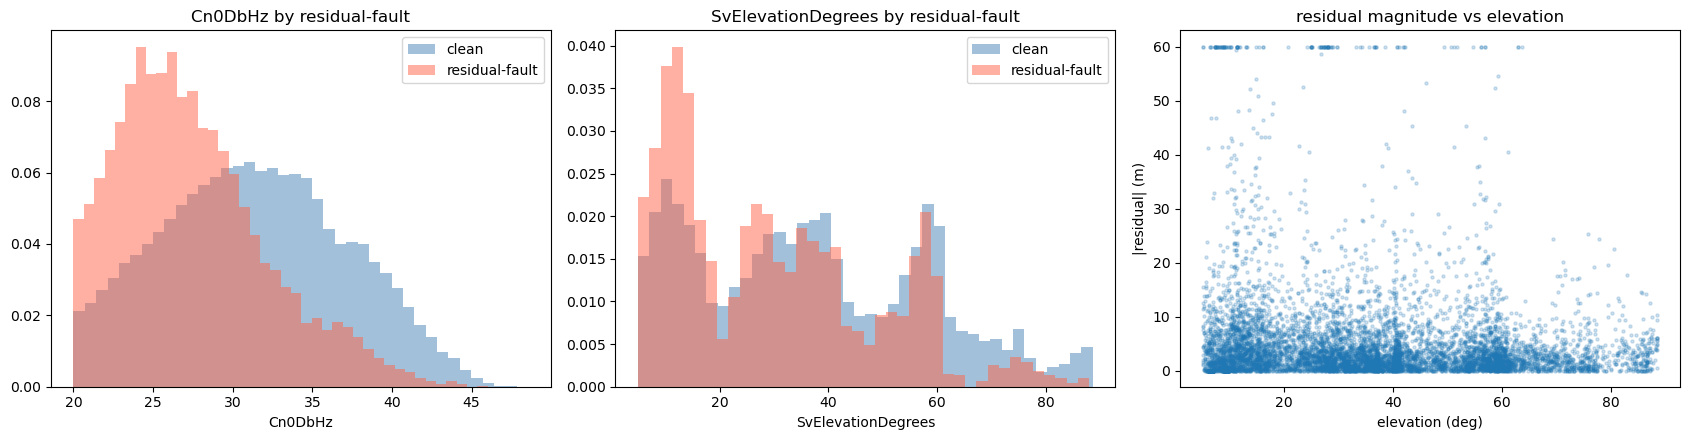

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(17,4.5))
for a,f in zip(ax[:2], ['Cn0DbHz','SvElevationDegrees']):
    for lab,col,nm in [(0,'steelblue','clean'),(1,'tomato','residual-fault')]:
        ax_=a; d=M[M.resid_fault==lab][f].dropna()
        a.hist(d, bins=40, alpha=0.5, density=True, color=col, label=nm)
    a.set_xlabel(f); a.set_title(f'{f} by residual-fault'); a.legend()
ax[2].scatter(M.sample(min(8000,len(M)),random_state=0).SvElevationDegrees,
              M.sample(min(8000,len(M)),random_state=0).abs_resid.clip(upper=60), s=5, alpha=0.2)
ax[2].set_xlabel('elevation (deg)'); ax[2].set_ylabel('|residual| (m)'); ax[2].set_title('residual magnitude vs elevation')
plt.tight_layout(); plt.show()

## 2. Integrity model — predicting an untrustworthy *epoch*

Even if per-satellite exclusion does not fix accuracy, a detector can serve **integrity**: warning a fusion filter when the whole fix is bad. We build epoch-level features (satellite count, C/N0 spread, elevation spread, multipath fraction, and **post-fit residual statistics against the shipped WLS solution** — all runtime-available) and predict whether the epoch's horizontal error exceeds its drive's 90th percentile.

In [6]:
def epoch_table(session, device):
    g = load_meas(session, device)
    # post-fit residuals vs the shipped WlsPosition (deployable, no ground truth)
    w = g.groupby('utcTimeMillis')[['WlsPositionXEcefMeters','WlsPositionYEcefMeters','WlsPositionZEcefMeters']].transform('first').values
    sat = g[['SvPositionXEcefMeters','SvPositionYEcefMeters','SvPositionZEcefMeters']].values
    pf = g.pr_corr.values - range_to(sat, w)
    g = g.assign(pf=pf)
    g['pf'] = g.pf - g.groupby(['utcTimeMillis','ConstellationType']).pf.transform('median')
    ep = g.groupby('utcTimeMillis').agg(n=('Cn0DbHz','size'), cn0_mean=('Cn0DbHz','mean'), cn0_std=('Cn0DbHz','std'),
        cn0_min=('Cn0DbHz','min'), elev_mean=('SvElevationDegrees','mean'), elev_min=('SvElevationDegrees','min'),
        mp_frac=('device_mp','mean'), pf_absmed=('pf', lambda s: s.abs().median()), pf_absmax=('pf', lambda s: s.abs().max())).reset_index()
    # position error from shipped WlsPosition
    gt = pd.read_csv(os.path.join(TRAIN, session, device, 'ground_truth.csv')).dropna(subset=['LatitudeDegrees','LongitudeDegrees']).sort_values('UnixTimeMillis')
    wls = g.groupby('utcTimeMillis')[['WlsPositionXEcefMeters','WlsPositionYEcefMeters','WlsPositionZEcefMeters']].first()
    la,lo = ecef_to_geo(wls.WlsPositionXEcefMeters.values, wls.WlsPositionYEcefMeters.values, wls.WlsPositionZEcefMeters.values)
    gi = np.clip(np.searchsorted(gt.UnixTimeMillis.values, wls.index.values),0,len(gt)-1)
    ep = ep.merge(pd.DataFrame({'utcTimeMillis':wls.index.values, 'err':hav(gt.LatitudeDegrees.values[gi], gt.LongitudeDegrees.values[gi], la, lo)}), on='utcTimeMillis')
    ep['bad'] = (ep.err > ep.err.quantile(0.90)).astype(int); ep['sess'] = session+'/'+device
    return ep

E = pd.concat([epoch_table(s,d) for s,d in SESSIONS], ignore_index=True)
print(f'Pooled epochs: {len(E):,}  |  bad-epoch rate {100*E.bad.mean():.1f}%')
EF = ['n','cn0_mean','cn0_std','cn0_min','elev_mean','elev_min','mp_frac','pf_absmed','pf_absmax']
Xe = E[EF].fillna(E[EF].median()); ye = E.bad.values; ge = E.sess.values
gkf2 = GroupKFold(n_splits=len(set(ge)) if len(set(ge))<=6 else 5)
print('\nIntegrity AUC (grouped CV, drives held out):')
print(f"  multipath-fraction alone     {roc_auc_score(ye, E.mp_frac):.3f}")
print(f"  post-fit residual median     {roc_auc_score(ye, E.pf_absmed):.3f}")
pe = cross_val_predict(RandomForestClassifier(300, max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=0, n_jobs=-1),
                       Xe, ye, groups=ge, cv=gkf2, method='predict_proba')[:,1]
print(f"  full epoch-feature RF        {roc_auc_score(ye, pe):.3f}")

Pooled epochs: 9,305  |  bad-epoch rate 10.0%

Integrity AUC (grouped CV, drives held out):
  multipath-fraction alone     0.534
  post-fit residual median     0.615


  full epoch-feature RF        0.568


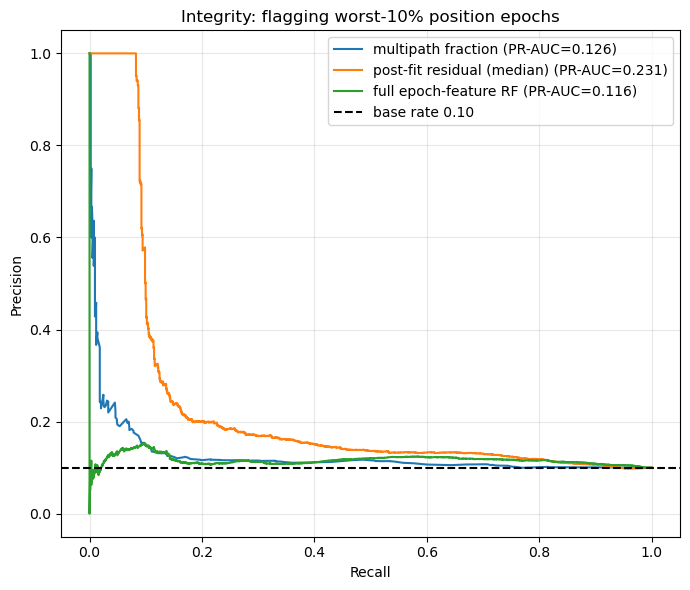

In [7]:
plt.figure(figsize=(7,6))
for name, sc in [('multipath fraction', E.mp_frac.values), ('post-fit residual (median)', E.pf_absmed.values), ('full epoch-feature RF', pe)]:
    pr, rc, _ = precision_recall_curve(ye, sc); plt.plot(rc, pr, label=f'{name} (PR-AUC={auc(rc,pr):.3f})')
plt.axhline(ye.mean(), color='k', ls='--', label=f'base rate {ye.mean():.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Integrity: flagging worst-10% position epochs'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Calibration — the cross-domain probability shift

Reliability curves: for well-calibrated probabilities, predicted probability should equal observed frequency (the diagonal). We train a shared-feature detector on SDC and plot its calibration on **SDC** (in-domain) versus **Warwick** (the simulation) — visualising why the decision threshold had to be recalibrated for transfer.

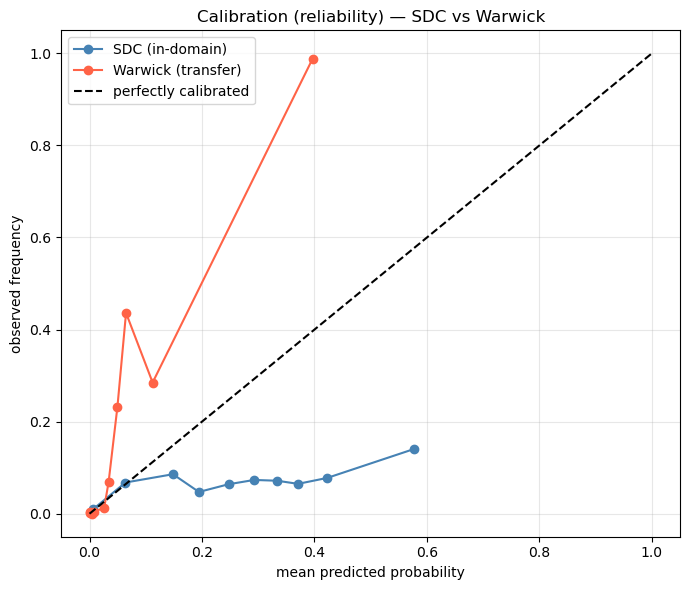

If the Warwick curve sits off the diagonal differently from SDC, the model is mis-calibrated across domains -> threshold recalibration is required.


In [8]:
# SDC shared-feature model + SDC in-domain calibration (grouped split)
SH = ['Cn0DbHz','SvElevationDegrees','az_sin','az_cos']
tr = M[M.sess != M.sess.unique()[-1]]; teS = M[M.sess == M.sess.unique()[-1]]
rf_sh = RandomForestClassifier(200, max_depth=16, class_weight='balanced', random_state=0, n_jobs=-1).fit(tr[SH], tr.device_mp.values)
p_sdc = rf_sh.predict_proba(teS[SH])[:,1]

# parse Warwick shared features
BLK = re.compile(r'(\w+)\(([^)]*)\)\s*=\s*\[(.*?)\]\s*;', re.S)
blk = lambda fn: BLK.findall('\n'.join(l for l in open(os.path.join(WARWICK,fn),errors='ignore').read().splitlines() if not l.startswith('//')))
ep_ = lambda i: int(i.split(',')[-1])
visi = {ep_(i):[int(x) for x in b.split()] for _,i,b in blk('Visibility.m')}
con = {ep_(i):np.array([[float(x) for x in r.split()] for r in b.split(';') if r.strip()]) for _,i,b in blk('Constellation.m')}
ch = {}
for _,i,b in blk('Channels.m'): ch[ep_(i)]={int(float(p[2])):float(p[4]) for p in (r.split() for r in b.split(';')) if len(p)>=5}
rec=[]
for t,arr in visi.items():
    if t not in con: continue
    Mx,c=con[t],ch.get(t,{})
    for k,v in enumerate(arr):
        if v==0: continue
        rec.append((np.degrees(Mx[k,10]), np.degrees(Mx[k,11])%360, c.get(int(Mx[k,0]),np.nan), 1 if v==1 else 0))
W = pd.DataFrame(rec, columns=['SvElevationDegrees','az','Cn0DbHz','y']).dropna()
W['az_sin']=np.sin(np.radians(W.az)); W['az_cos']=np.cos(np.radians(W.az))
p_war = rf_sh.predict_proba(W[SH])[:,1]

plt.figure(figsize=(7,6))
for name, y_, p_, col in [('SDC (in-domain)', teS.device_mp.values, p_sdc, 'steelblue'), ('Warwick (transfer)', W.y.values, p_war, 'tomato')]:
    fx, fy = calibration_curve(y_, p_, n_bins=10, strategy='quantile')
    plt.plot(fy, fx, 'o-', color=col, label=name)
plt.plot([0,1],[0,1],'k--', label='perfectly calibrated')
plt.xlabel('mean predicted probability'); plt.ylabel('observed frequency'); plt.title('Calibration (reliability) — SDC vs Warwick')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('If the Warwick curve sits off the diagonal differently from SDC, the model is mis-calibrated across domains -> threshold recalibration is required.')

## 4. Booster & ensemble (completeness)

A HistGradientBoosting booster and a soft-voting ensemble (RF + HGB), against the Random Forest, on a session-held-out split. Kept deliberately small — on this saturated problem the models cluster; the point is completeness, not a leaderboard.

In [9]:
trX, trY = tr[FEATS].fillna(tr[FEATS].median()), tr.device_mp.values
teX, teY = teS[FEATS].fillna(tr[FEATS].median()), teS.device_mp.values
rf  = RandomForestClassifier(200, max_depth=16, class_weight='balanced', random_state=0, n_jobs=-1)
hgb = HistGradientBoostingClassifier(max_iter=250, random_state=0)
vote = VotingClassifier([('rf',rf),('hgb',hgb)], voting='soft', n_jobs=-1)
tbl=[]
for nm, m in [('Random Forest', rf), ('HistGradientBoosting', hgb), ('Voting (RF+HGB)', vote)]:
    m.fit(trX, trY); p = m.predict_proba(teX)[:,1]; pr,rc,_ = precision_recall_curve(teY,p)
    tbl.append({'model':nm, 'roc_auc':round(roc_auc_score(teY,p),4), 'pr_auc':round(auc(rc,pr),4),
                'f1@0.5':round(f1_score(teY,(p>=0.5).astype(int)),4)})
print(pd.DataFrame(tbl).to_string(index=False))

               model  roc_auc  pr_auc  f1@0.5
       Random Forest   0.8052  0.2532  0.2527
HistGradientBoosting   0.8087  0.2094  0.1962
     Voting (RF+HGB)   0.8053  0.2457  0.2678


## 5. Takeaways

- **The device flag is a noisy label.** The residual-fault label (physically inconsistent measurements) and the device `MultipathIndicator` overlap poorly — they flag largely *different* measurements — confirming the device flag is not a clean measurement-error ground truth.
- **The physics-based residual label is a cleaner target** — it is more predictable from signal + geometry than the device flag, and its predictors (low C/N0, low elevation) are the expected physical ones.
- **Integrity is possible but modest:** multipath fraction alone is uninformative about bad-position epochs, but post-fit residual statistics carry a moderate integrity signal — the useful framing for a fusion filter.
- **Calibration shifts across domains,** which is why the SDC->Warwick transfer needed threshold recalibration; the reliability curves make this explicit.
- **Booster/ensemble** perform on par with the Random Forest — the problem is saturated, so model choice is not the lever; label quality and framing are.